# ILP VRPTW vs TOPTW

Notebooks 1-6 build VRP variants on top of OR-Tools' **routing solver** (a constraint-programming engine with VRP-specific abstractions). This notebook drops down a level and writes two of those problems as **arc-flow ILPs** solved with **OR-Tools CP-SAT** instead. The point isn't performance — the routing solver is faster on the same problem — it's to see the constraints in their unwrapped form.

Why this matters: the user's next problem is **satellite scheduling**, where the abstractions VRP gives you (vehicles, depots, time windows, capacity) don't fit cleanly. An imaging satellite over a target is more like an *orienteering* problem: you have a budget (an orbital pass), candidate observations carry priorities, and you skip the ones you can't fit. TOPTW is the closest classical sibling.

Two formulations, same skeleton:

| | VRPTW (ILP) | TOPTW (ILP) |
|---|---|---|
| visit obligation | every customer **must** be visited | each customer is **optional** |
| objective | minimise total distance | maximise collected profit |
| per-vehicle limit | capacity | route duration budget `T_max` |
| infeasible if... | windows + capacity don't fit | (never — always feasible, just drop nodes) |

Library entry points used below: `solve_vrptw_ilp`, `solve_toptw_ilp` (both in `src/vrp_lib/solver_ilp.py`).

In [1]:
%load_ext autoreload
%autoreload 2

import random

import numpy as np

from vrp_lib import (
    euclidean_distance_matrix,
    plot_routes,
    solve_toptw_ilp,
    solve_vrptw_ilp,
)

random.seed(7)
np.random.seed(7)

## 1. A shared instance

Six customers around a central depot in a 40×40 grid. Travel speed 1 unit per minute, so distance == minutes. A few customers have tight windows so the TOPTW budget below has bite.

Same coordinates, demands, and windows go into both solvers; only the objective and the per-vehicle constraint change.

In [2]:
DEPOT = 0
HORIZON = 240
SERVICE_TIME = 5

points = [
    (20, 20),  # 0 depot
    (35, 20),  # 1
    (20, 35),  # 2
    ( 5, 20),  # 3
    (20,  5),  # 4
    (32, 32),  # 5
    ( 8,  8),  # 6
]
demands  = [0, 3, 2, 4, 3, 5, 2]
profits  = [0, 4, 3, 5, 4, 6, 2]
windows  = [
    (0, HORIZON),  # depot
    (10,  80),
    (20,  90),
    (40, 110),
    (60, 130),
    (80, 150),
    (100, 170),
]

distance = euclidean_distance_matrix(points)
for row in distance:
    print(row)

[0, 15, 15, 15, 15, 17, 17]
[15, 0, 21, 30, 21, 12, 30]
[15, 21, 0, 21, 30, 12, 30]
[15, 30, 21, 0, 21, 30, 12]
[15, 21, 30, 21, 0, 30, 12]
[17, 12, 12, 30, 30, 0, 34]
[17, 30, 30, 12, 12, 34, 0]


## 2. VRPTW as an arc-flow ILP

**Decision variables**

$$
x_{ijk} \in \{0, 1\} \quad \text{arc } i \to j \text{ is used by vehicle } k
$$
$$
t_{ik} \in [a_i, b_i] \quad \text{arrival time of vehicle } k \text{ at node } i
$$
$$
\ell_{ik} \in [0, Q_k] \quad \text{cumulative load on } k \text{ at node } i
$$

**Constraints**

1. Each customer is visited by exactly one vehicle: $\sum_k \sum_j x_{ijk} = 1\;\;\forall i \neq \text{depot}$.
2. Flow conservation: $\sum_i x_{ihk} = \sum_j x_{hjk}\;\;\forall h \neq \text{depot}, k$.
3. Each vehicle leaves and returns to the depot exactly once.
4. Time propagation, activated only when the arc is used:
   $$ x_{ijk} = 1 \;\Rightarrow\; t_{jk} \geq t_{ik} + s_i + d_{ij} $$
5. Capacity propagation, same idea:
   $$ x_{ijk} = 1 \;\Rightarrow\; \ell_{jk} \geq \ell_{ik} + q_j $$

**Objective:** $\min \sum_{i,j,k} d_{ij} \, x_{ijk}$.

**Subtour elimination is implicit.** Any cycle disjoint from the depot would force $t_{ik}$ to strictly increase around it, which is impossible. CP-SAT's `OnlyEnforceIf` is the modelling primitive that gives us “this constraint only holds when this boolean is true” — cleaner than the textbook big-M encoding $t_{jk} \geq t_{ik} + s_i + d_{ij} - M(1 - x_{ijk})$.

In [3]:
vrptw = solve_vrptw_ilp(
    distance, demands, windows,
    vehicle_capacities=[10, 10],
    service_time=SERVICE_TIME,
    horizon=HORIZON,
    time_limit_seconds=10,
)

print(f"status={vrptw.status}  total_distance={vrptw.total_distance}")
for k, route in enumerate(vrptw.routes):
    print(f"  vehicle {k}: {route}  load={vrptw.loads[k]}")
print("\nschedule (arrive @ node):")
for entry in vrptw.schedule:
    print(f"  v{entry['vehicle']}  n{entry['node']}  arrive={entry['arrive']}  leave={entry['leave']}")

status=1  total_distance=119
  vehicle 0: [0, 1, 2, 5, 0]  load=10
  vehicle 1: [0, 3, 6, 4, 0]  load=9

schedule (arrive @ node):
  v0  n0  arrive=0  leave=0
  v0  n1  arrive=15  leave=20
  v0  n2  arrive=41  leave=46
  v0  n5  arrive=80  leave=85
  v0  n0  arrive=240  leave=240
  v1  n0  arrive=0  leave=0
  v1  n3  arrive=40  leave=45
  v1  n6  arrive=100  leave=105
  v1  n4  arrive=117  leave=122
  v1  n0  arrive=240  leave=240


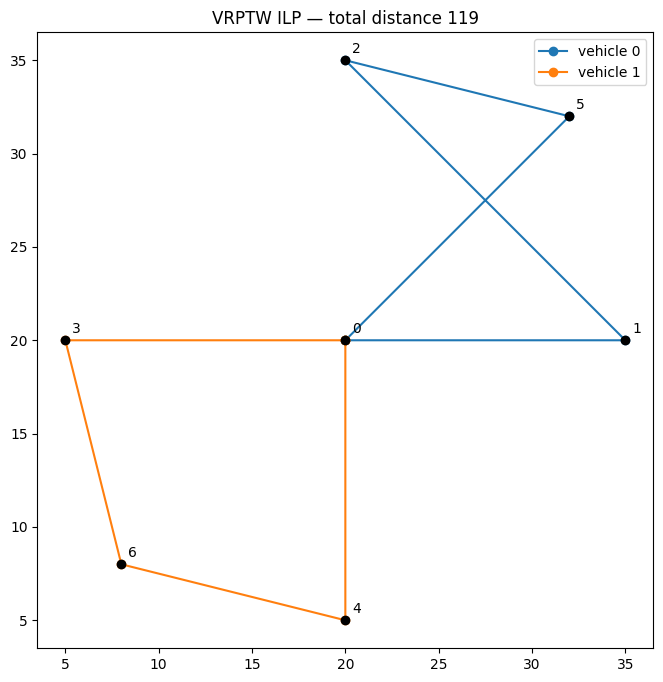

In [4]:
plot_routes(points, vrptw.routes, title=f"VRPTW ILP — total distance {vrptw.total_distance}")

## 3. TOPTW: four deltas from the VRPTW ILP

Same arc-flow skeleton ($x_{ijk}$, $t_{ik}$). Four changes:

1. **Optional visits.** Add $y_i \in \{0,1\}$ for each customer with $\sum_k \sum_j x_{ijk} = y_i$. The visit-every-customer equality is replaced by this definition; if $y_i = 0$, no arc enters $i$.
2. **Profit objective.** $\max \sum_i p_i \, y_i$.
3. **Route duration budget.** A new variable $t^{\text{end}}_k$, bounded above by $T_\max$, captures each vehicle's return time. The capacity constraint is *optional*.
4. **Vehicles may stay home.** $\sum_j x_{0jk} \leq 1$ (not $= 1$) so a vehicle can visit zero customers — important when the budget can't fit anything.

Below we set `t_max=110` so each vehicle's round-trip budget can't cover every customer — TOPTW has to decide which to skip.

In [5]:
toptw = solve_toptw_ilp(
    distance, profits, windows,
    num_vehicles=2,
    t_max=110,
    service_time=SERVICE_TIME,
    horizon=HORIZON,
    time_limit_seconds=10,
)

print(f"status={toptw.status}  total_profit={toptw.total_profit}  total_distance={toptw.total_distance}")
print(f"dropped customers: {toptw.dropped}")
for k, route in enumerate(toptw.routes):
    print(f"  vehicle {k}: {route}")
print("\nschedule (arrive @ node):")
for entry in toptw.schedule:
    print(f"  v{entry['vehicle']}  n{entry['node']}  arrive={entry['arrive']}  leave={entry['leave']}")

status=1  total_profit=22  total_distance=125
dropped customers: [6]
  vehicle 0: [0, 2, 4, 3, 0]
  vehicle 1: [0, 1, 5, 0]

schedule (arrive @ node):
  v0  n0  arrive=0  leave=0
  v0  n2  arrive=20  leave=25
  v0  n4  arrive=60  leave=65
  v0  n3  arrive=86  leave=91
  v0  n0  arrive=110  leave=110
  v1  n0  arrive=0  leave=0
  v1  n1  arrive=15  leave=20
  v1  n5  arrive=88  leave=93
  v1  n0  arrive=110  leave=110


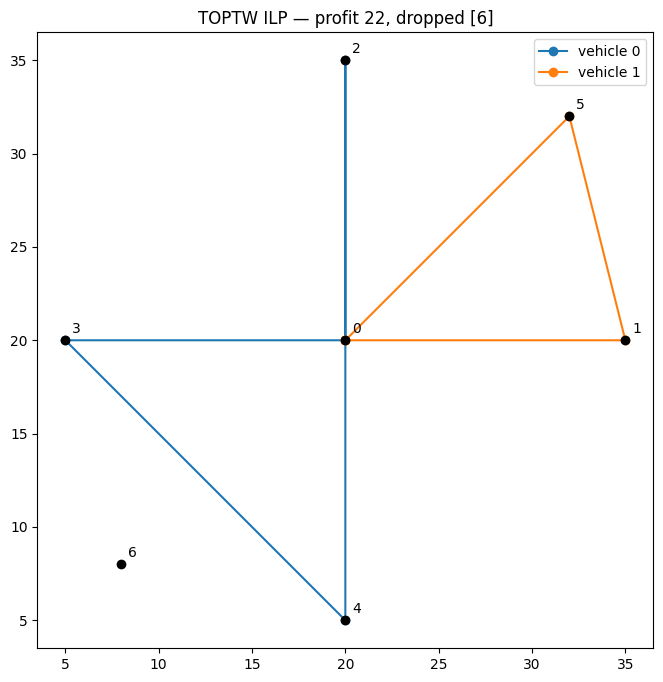

In [6]:
plot_routes(points, toptw.routes, title=f"TOPTW ILP — profit {toptw.total_profit}, dropped {toptw.dropped}")

## 4. Side-by-side

| dimension | VRPTW ILP | TOPTW ILP |
|---|---|---|
| objective | minimise $\sum d_{ij} x_{ijk}$ | maximise $\sum p_i y_i$ |
| visit obligation | every customer (equality) | optional (definition of $y_i$) |
| per-vehicle limit | capacity $Q_k$ | duration $T_\max$ |
| empty vehicle? | not allowed (must serve demand) | allowed |
| infeasibility | possible | only when problem data itself is broken |
| dropped output | always empty | populated when the budget bites |

The variables and most constraints are shared. **One model becomes the other by changing the objective, swapping the visit-equality for an indicator, and adding `t_end[k] <= T_max`.** That's the entire reason we wrote both from the same skeleton.

In [7]:
print("VRPTW ILP")
print(f"  total_distance : {vrptw.total_distance}")
print(f"  customers      : visited all")
print(f"  vehicles used  : {sum(1 for r in vrptw.routes if len(r) > 2)}")
print()
print("TOPTW ILP")
print(f"  total_profit   : {toptw.total_profit} (max possible {sum(profits[1:])})")
print(f"  total_distance : {toptw.total_distance} (secondary metric)")
print(f"  dropped        : {toptw.dropped}")
print(f"  vehicles used  : {sum(1 for r in toptw.routes if len(r) > 2)}")

VRPTW ILP
  total_distance : 119
  customers      : visited all
  vehicles used  : 2

TOPTW ILP
  total_profit   : 22 (max possible 24)
  total_distance : 125 (secondary metric)
  dropped        : [6]
  vehicles used  : 2


## 5. Bridge to satellite scheduling

The mapping from TOPTW to a single-satellite imaging-scheduling problem:

| TOPTW concept | Satellite analogue |
|---|---|
| depot | ground station (or orbit start) |
| customer | imaging target |
| customer time window | the visibility window during which a target is over the sensor's swath |
| service time | slew + integration time per target |
| `T_max` | orbital pass duration or duty-cycle budget |
| profit | image priority / scientific value |
| vehicle | a single satellite (or each satellite in a constellation, for the *team* version) |

What this notebook deliberately does *not* model and will need to be added for satellites:

- **Slew-dependent transition times.** Travel `d_ij` in VRP is symmetric and depot-independent. Slew time on a satellite depends on the body's current attitude after observing $i$, which can be encoded by making $d_{ij}$ asymmetric.
- **Energy / data-buffer state.** Like load, but draining instead of accumulating, and tied to ground-contact passes for downlink. Reuse the load-propagation pattern.
- **Multiple visibility windows per target per orbit.** Encode each opportunity as a separate node with the *same* profit and a constraint $\sum_{\text{copies}} y_i \leq 1$.

Each of those is a straightforward addition on top of the TOPTW formulation — they don't require a new framework, just more constraints in the same arc-flow ILP. The fact that CP-SAT happily mixes booleans, integers, and `OnlyEnforceIf` makes that incremental approach realistic.

## Where to go next

- The arc-flow formulation has $O(K \cdot n^2)$ booleans. For learning instances ($n \leq 15$) that's fine; for satellite-scale problems ($n \geq 100$, multiple opportunities per target) it grows fast. The standard fix is **column generation** or **branch-and-price**: enumerate routes implicitly as columns of a master LP and only generate the promising ones.
- For benchmarking, the Solomon (VRPTW) and Cordeau (TOPTW) instance sets are the canonical references.